In [1]:
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import numpy as np
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import cmocean as cmo
#import pyrtlib as rtl
import time

import atmo3 as a3

In [2]:
# Turbulence injection scales: the wavenumber k0 = 2π/L_inj marks the peak
# of the power spectrum, i.e. the scale at which turbulent energy is injected.
q_injection_scale_in_m  = 500.0  # Water-vapour injection scale (m)
ta_injection_scale_in_m = 200.0  # Temperature injection scale (m)
cloud_injection_scale_in_m  = 2000.0  # Cloud-injection scale (m)

# Grid dimensions [Nx, Ny, Nz] and physical box size [Lx, Ly, Lz] in metres.
# The horizontal resolution is Lx/Nx ≈ 39 m; the vertical is Lz/Nz ≈ 39 m.
nside_grid = [256, 256, 128]
box_length = [22000., 22000., 11000.]

boresight  = jnp.array([box_length[0]//2., box_length[1]//2.])
passband   = {'nu': jnp.array([150.]), 'g(nu)': jnp.array([1.])}
fwhm       = 10.

# APEX observatory: altitude 5100 m a.s.l., Llano de Chajnantor, Chile.
site_altitude = 5100.
site_coordinates = [-67.78, -22.95]  # [longitude, latitude] in degrees

# Simulation epoch in UTC.  ERA5 profiles and APEX weather data are
# selected from a ±30-minute window centred on this timestamp.
time_utc = datetime(2023, 10, 4, 17, 0, tzinfo=timezone.utc) #day with clouds

t0 = time.perf_counter()
# =============================================================================
# Scan strategy
# =============================================================================

# dt = 0 case
timesamples = [np.datetime64(time_utc)]
az          = [0.]      # in deg
el          = [45.]     # in deg

# remaining 300 samples
for sample in range(300-1):
    timesamples.append(timesamples[-1] + np.timedelta64(200, 'ms'))
    az.append(az[-1] + 0.2)
    el.append(el[-1]) 
    
t1 = time.perf_counter()

print(f"Scan setup time : {t1 - t0:.6f} s")

Scan setup time : 0.001066 s


/tmp/ipykernel_788105/4114334367.py:30: UserWarning: no explicit representation of timezones available for np.datetime64
  timesamples = [np.datetime64(time_utc)]


In [3]:
# =============================================================================
# Input data paths
# =============================================================================

atmo3_data = '/pscratch/sd/s/shamikg/atmo3_data/'

# ERA5 pressure-level files covering the APEX region (291–293 °E, 24–22 °S)
# at 0.25° resolution for October 2023.
geopotfile = f'{atmo3_data}era5/2023/geopt.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
tempfile   = f'{atmo3_data}era5/2023/ta.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
spechfile  = f'{atmo3_data}era5/2023/q.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'

ccfile     = f'{atmo3_data}era5/2023/cc.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'      # Cloud cover fraction
ciwcfile   = f'{atmo3_data}era5/2023/ciwc.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'    # Cloud ice water content
clwcfile   = f'{atmo3_data}era5/2023/clwc.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'    # Cloud liquid water content

northwindfile = f'{atmo3_data}era5/2023/v.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'      # V-component North wind
eastwindfile  = f'{atmo3_data}era5/2023/u.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'      # U-component East wind

# APEX weather-station CSV (columns: UT, PWV, Temperature, Humidity,
# Wind_Dir, Wind_Speed) spanning 2006–2025.
apexfile = f'{atmo3_data}apex/meteo_apex_2006_2025.csv'

# =============================================================================
# Initialise the atmosphere object
# ERA5 profiles are read and interpolated to the site location; profiles are
# then normalised so that the ground-level temperature and column-integrated
# PWV match the mean APEX observations recorded within ±30 min of time_utc.
# =============================================================================
atmo_box = a3.Atmosphere(
    nside_grid=nside_grid,
    box_length_in_m=box_length,
    site_altitude=site_altitude,
    site_coordinates=site_coordinates,
    time_utc=time_utc,
    geopotential_file_era5=geopotfile,
    temperature_file_era5=tempfile,
    spec_humidity_file_era5=spechfile,
    cloud_cover_file_era5=ccfile,
    cloud_ice_water_content_file_era5=ciwcfile,
    cloud_liquid_water_content_file_era5=clwcfile,
    apex_datafile=apexfile
)




0.70672131147541 0.07471548950240973


In [4]:
k_array = np.arange(4*nside_grid[0]) * jnp.min(atmo_box.grid_wsp.dk)

k0_q  = 2*np.pi / q_injection_scale_in_m   # Water-vapour injection wavenumber (rad/m)
k0_ta = 2*np.pi / ta_injection_scale_in_m  # Temperature injection wavenumber (rad/m)

k0_cloud = 2*np.pi / cloud_injection_scale_in_m  # Cloud injection wavenumber (rad/m)

pofk_q  = ( k0_q**2.  + k_array**2 )**-(11/6)
pofk_ta = ( k0_ta**2. + k_array**2 )**-(11/6)
pofk_cloud = ( k0_cloud**2. + k_array**2 )**-(11/6)

# Normalise to peak = 1; absolute RMS amplitudes come from calibration.
pofk_q  /= np.max(pofk_q)
pofk_ta /= np.max(pofk_ta)
pofk_cloud /= np.max(pofk_cloud)

# Pack into dictionaries expected by add_temperature / add_watervapor.
pspec_q  = {'k': k_array, 'pofk': pofk_q}
pspec_ta = {'k': k_array, 'pofk': pofk_ta}
pspec_cloud = {'k': k_array, 'pofk': pofk_cloud}

z_scale = atmo_box.super_grid.z


atmo_box.add_ice_liquid_cloud(
        power_spec = pspec_cloud,
        seed = 42,
    ) 

atmo_box.generate_realization(time_step=0, component_name='ice water')

Random field : 20.773815 s
Apply P(k) : 13.869841 s
IRFFT : 0.059418 s
Rescaled field : 0.526890 s


In [5]:
ice_cube = atmo_box.derived_cubes['ice water']

In [ ]:
cc_interp = atmo_box.super_grid.era5_interp2site(ccfile)
ciwc_interp = atmo_box.super_grid.era5_interp2site(ciwcfile)
clwc_interp = atmo_box.super_grid.era5_interp2site(clwcfile)

fluctuations_cloud = atmo_box.components['fluctuations for clouds'].field

In [ ]:
import jax
import jax.numpy as jnp

# ==============================================================================
# 1. Derive the 3D Cloud Mask using the Fluctuations Field
# ==============================================================================

nz = fluctuations_cloud.shape[2]

# Flatten the spatial (x, y) dimensions to calculate quantiles per z-layer easily
# New shape: (nz, nx * ny)
fluct_flat = jnp.transpose(fluctuations_cloud, (2, 0, 1)).reshape(nz, -1)

# Calculate target quantiles based on ERA5 Cloud Cover (cc_interp)
# Example: If cc_interp is 0.3 (30% cloud cover), we want the top 30% of fluctuations.
# Therefore, our threshold is the 70th percentile (0.7).
q_targets = jnp.clip(1.0 - cc_interp, 0.0, 1.0)

# Vectorize the quantile calculation across all altitude layers simultaneously
layer_thresholds = jax.vmap(jnp.quantile)(fluct_flat, q_targets)

# Broadcast the 1D thresholds and CC profiles back to 3D compatible shapes (1, 1, nz)
thresholds_3d = layer_thresholds.reshape(1, 1, nz)
cc_3d = cc_interp.reshape(1, 1, nz)

# Create binary mask: 
# It gets a 1 ONLY if the fluctuation is above the threshold AND ERA5 cc > 0
cloud_mask = jnp.where(cc_3d > 0.0, fluctuations_cloud >= thresholds_3d, 0).astype(jnp.int8)


# ==============================================================================
# 2. Derive the 3D Ice and Liquid Cubes
# ==============================================================================

# --- Process Cloud Ice Water Content (CIWC) ---
# Calculate in-cloud ice concentration: ciwc / cc
# We use jnp.where to prevent divide-by-zero errors in clear-sky layers
ice_ratio_1d = jnp.where(cc_interp > 0.0, ciwc_interp / cc_interp, 0.0)

# Map the 1D concentration profile exclusively into the active 3D cloud voxels
ice_cube = cloud_mask * ice_ratio_1d.reshape(1, 1, -1)


# --- Process Cloud Liquid Water Content (CLWC) ---
# Calculate in-cloud liquid concentration: clwc / cc
liquid_ratio_1d = jnp.where(cc_interp > 0.0, clwc_interp / cc_interp, 0.0)

# Map the 1D concentration profile exclusively into the active 3D cloud voxels
liquid_cube = cloud_mask * liquid_ratio_1d.reshape(1, 1, -1)

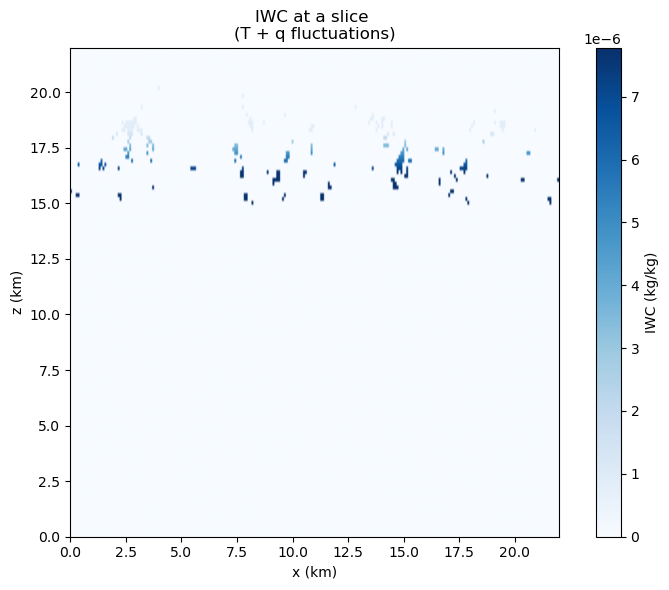

In [ ]:
iwc_slice = ice_cube[:, nside_grid[1]//2, :]

plt.figure(figsize=(8,6))
plt.imshow(iwc_slice.T, origin='lower', cmap='Blues',
           extent=[0, box_length[0]/1000, 0, box_length[1]/1000])
plt.title(f'IWC at a slice \n(T + q fluctuations)')
plt.colorbar(label='IWC (kg/kg)')
plt.xlabel('x (km)')
plt.ylabel('z (km)')
plt.tight_layout()
plt.show()